In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest

In [2]:
df_churn=pd.read_csv("Data Set For Task/Churn Prdiction Data/churn-bigml-20.csv")
df_churn.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,LA,117,408,No,No,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,False
1,IN,65,415,No,No,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4,True
2,NY,161,415,No,No,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,True
3,SC,111,415,No,No,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,False
4,HI,49,510,No,No,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,False


In [4]:
df_churn.shape

(667, 20)

In [5]:
df_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 667 entries, 0 to 666
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   667 non-null    object 
 1   Account length          667 non-null    int64  
 2   Area code               667 non-null    int64  
 3   International plan      667 non-null    object 
 4   Voice mail plan         667 non-null    object 
 5   Number vmail messages   667 non-null    int64  
 6   Total day minutes       667 non-null    float64
 7   Total day calls         667 non-null    int64  
 8   Total day charge        667 non-null    float64
 9   Total eve minutes       667 non-null    float64
 10  Total eve calls         667 non-null    int64  
 11  Total eve charge        667 non-null    float64
 12  Total night minutes     667 non-null    float64
 13  Total night calls       667 non-null    int64  
 14  Total night charge      667 non-null    fl

outlier removal using isolation forest in multiple features

In [12]:
X = df_churn.select_dtypes(include=[np.number])
# Initialize the model
iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
# Fit the model
iso_forest.fit(X)
# Predict anomalies
df_churn['anomaly'] = iso_forest.predict(X)
df_no_outliers=df_churn[df_churn.anomaly!=-1]
df_no_outliers.info()

<class 'pandas.core.frame.DataFrame'>
Index: 633 entries, 0 to 665
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   633 non-null    object 
 1   Account length          633 non-null    int64  
 2   Area code               633 non-null    int64  
 3   International plan      633 non-null    object 
 4   Voice mail plan         633 non-null    object 
 5   Number vmail messages   633 non-null    int64  
 6   Total day minutes       633 non-null    float64
 7   Total day calls         633 non-null    int64  
 8   Total day charge        633 non-null    float64
 9   Total eve minutes       633 non-null    float64
 10  Total eve calls         633 non-null    int64  
 11  Total eve charge        633 non-null    float64
 12  Total night minutes     633 non-null    float64
 13  Total night calls       633 non-null    int64  
 14  Total night charge      633 non-null    float64

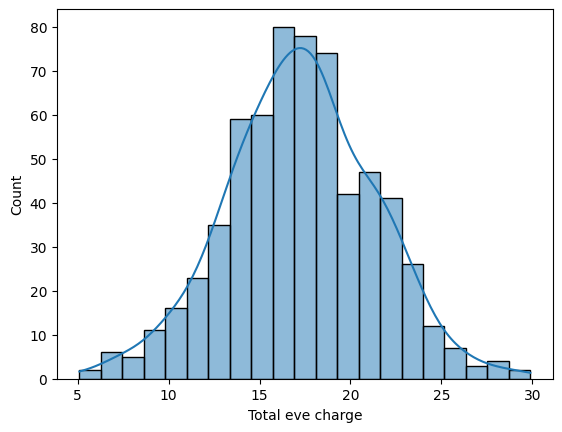

In [16]:
sns.histplot(data=df_no_outliers,x="Total eve charge",kde=True,label="Total eve calls")
plt.show()

In [27]:
df_no_outliers['churn_encoded'] = df_no_outliers['Churn'].astype(int)
df_no_outliers.drop(columns="anomaly",inplace=True)
df_no_outliers.head()

C:\Users\user\AppData\Local\Temp\ipykernel_13544\326186977.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_outliers['churn_encoded'] = df_no_outliers['Churn'].astype(int)
C:\Users\user\AppData\Local\Temp\ipykernel_13544\326186977.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_outliers.drop(columns="anomaly",inplace=True)


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,...,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn,churn_encoded
0,LA,117,408,No,No,0,184.5,97,31.37,351.6,...,29.89,215.8,90,9.71,8.7,4,2.35,1,False,0
1,IN,65,415,No,No,0,129.1,137,21.95,228.5,...,19.42,208.8,111,9.40,12.7,6,3.43,4,True,1
3,SC,111,415,No,No,0,110.4,103,18.77,137.3,...,11.67,189.6,105,8.53,7.7,6,2.08,2,False,0
4,HI,49,510,No,No,0,119.3,117,20.28,215.1,...,18.28,178.7,90,8.04,11.1,1,3.00,1,False,0
5,AK,36,408,No,Yes,30,146.3,128,24.87,162.5,...,13.81,129.3,109,5.82,14.5,6,3.92,0,False,0


In [30]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, FunctionTransformer
import pandas as pd

# Step 1: Define your DataFrame
df = df_no_outliers.copy()

# Step 2: Identify columns
numerical_cols = df.select_dtypes(include='number').columns.tolist()
binary_cols = df.select_dtypes(include='bool').columns.tolist()

# Step 3: Define transformers
# Encode binary columns (True/False → 1/0)
binary_encoder = FunctionTransformer(lambda x: x.astype(int))

# Choose scaler: StandardScaler or MinMaxScaler
scaler = StandardScaler()  # or MinMaxScaler()

# Step 4: Build ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', scaler, numerical_cols),
        ('bin', binary_encoder, binary_cols)
    ],
    remainder='drop'  # Drop other columns unless you want to keep them
)

# Step 5: Apply the pipeline
df_processed = preprocessor.fit_transform(df)

# Optional: Convert back to DataFrame with column names
processed_cols = numerical_cols + binary_cols
df_final = pd.DataFrame(df_processed, columns=processed_cols)
df_final.head()

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,churn_encoded,Churn
0,0.356218,-0.652593,-0.574679,0.055280,-0.185187,0.055760,3.100364,-1.106902,3.101312,0.359524,-0.481918,0.358991,-0.598086,-0.215968,-0.597498,-0.431729,-0.404479,0.0
1,-0.931143,-0.481094,-0.574679,-0.971172,1.809255,-0.970912,0.532451,-0.945221,0.531824,0.212960,0.576247,0.214770,0.915813,0.605100,0.916376,1.890801,2.472319,1.0
2,0.207677,-0.481094,-0.574679,-1.317645,0.113979,-1.317495,-1.370017,0.078754,-1.370137,-0.189045,0.273914,-0.189980,-0.976560,0.605100,-0.975966,0.342448,-0.404479,0.0
3,-1.327254,1.846388,-0.574679,-1.152746,0.812034,-1.152923,0.252921,0.456008,0.252052,-0.417267,-0.481918,-0.417942,0.310254,-1.447571,0.313630,-0.431729,-0.404479,0.0
4,-1.649094,-0.652593,1.643442,-0.652490,1.360505,-0.652665,-0.844335,-1.106902,-0.844950,-1.451593,0.475470,-1.450752,1.597067,0.605100,1.603226,-1.205905,-0.404479,0.0


test train split

In [32]:
from sklearn.model_selection import train_test_split
X = df_final.drop(columns=['Churn','churn_encoded'])
Y =y = df_final['Churn']

# Step 2: Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Initialize and train
model = LogisticRegression()
LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.889763779527559
              precision    recall  f1-score   support

         0.0       0.89      0.99      0.94       109
         1.0       0.83      0.28      0.42        18

    accuracy                           0.89       127
   macro avg       0.86      0.63      0.68       127
weighted avg       0.88      0.89      0.87       127



knn algorithm

In [42]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize the model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.889763779527559
              precision    recall  f1-score   support

         0.0       0.89      0.99      0.94       109
         1.0       0.83      0.28      0.42        18

    accuracy                           0.89       127
   macro avg       0.86      0.63      0.68       127
weighted avg       0.88      0.89      0.87       127



In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],  # 'liblinear' supports both l1 and l2
    'max_iter': [100, 200, 500]
}

# Initialize the model
logreg = LogisticRegression()

# Set up GridSearchCV
grid_search = GridSearchCV(logreg, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Best parameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)

Best Parameters: {'C': 1, 'max_iter': 100, 'penalty': 'l2', 'solver': 'liblinear'}
Best Accuracy: 0.8616191030867792


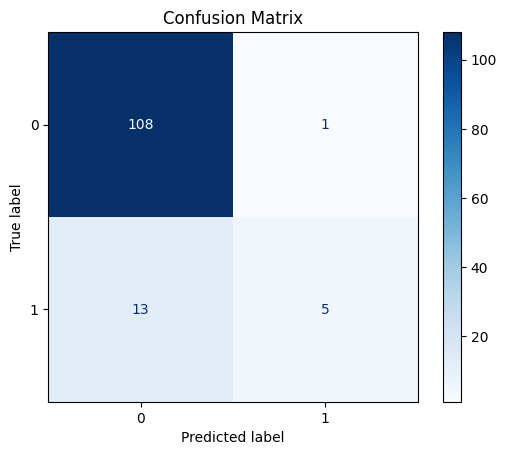

In [47]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate predictions (already done)
# y_pred = model.predict(X_test)

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot it
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()